In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
import math
import textwrap
import re
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
df_test = pd.read_csv('GermanTrafficSign/Test.csv')
df_meta = pd.read_csv('GermanTrafficSign/Meta.csv')

In [4]:
df_test

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png
...,...,...,...,...,...,...,...,...
12625,42,41,5,6,37,36,12,Test/12625.png
12626,50,51,6,5,45,46,33,Test/12626.png
12627,29,29,6,6,24,24,6,Test/12627.png
12628,48,49,5,6,43,44,7,Test/12628.png


In [5]:
df_meta

,Path,ClassId,ShapeId,ColorId,SignId
0,Meta/27.png,27,0,0,1.32
1,Meta/0.png,0,1,0,3.29
2,Meta/1.png,1,1,0,3.29
3,Meta/10.png,10,1,0,3.27
4,Meta/11.png,11,0,0,1.22
5,Meta/12.png,12,2,2,2.3
6,Meta/13.png,13,4,0,2.1
7,Meta/14.png,14,3,0,2.2
8,Meta/15.png,15,1,0,3.1
9,Meta/16.png,16,1,0,3.3


# Przedstawienie wszystkich znaków drogowych (klas wytrenowanego modelu)

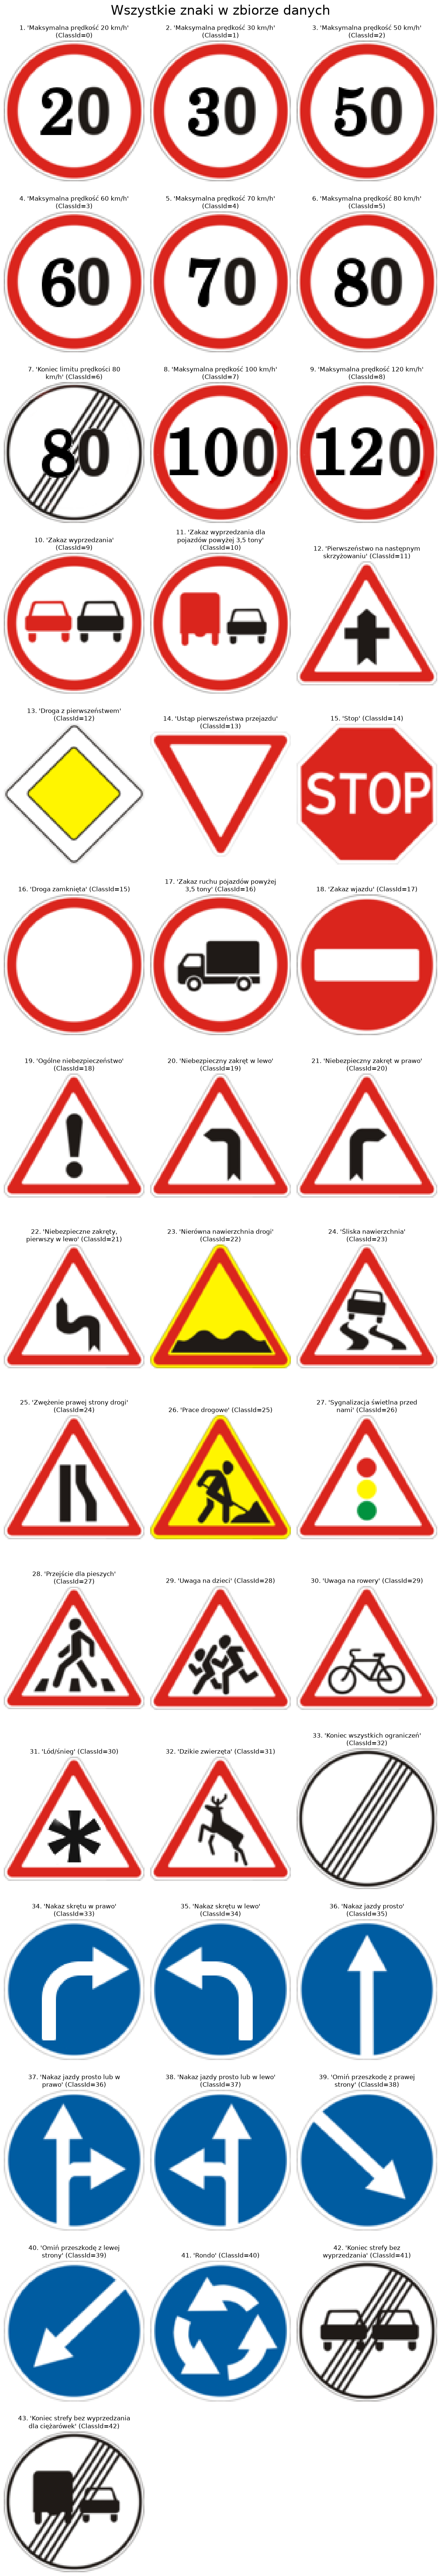

In [6]:
# https://www.geeksforgeeks.org/pandas/how-to-sort-pandas-dataframe/
# https://www.geeksforgeeks.org/python/reset-index-in-pandas-dataframe/
road_sign_name = {0: 'Maksymalna prędkość 20 km/h',
                  1: 'Maksymalna prędkość 30 km/h',
                  2: 'Maksymalna prędkość 50 km/h',
                  3: 'Maksymalna prędkość 60 km/h',
                  4: 'Maksymalna prędkość 70 km/h',
                  5: 'Maksymalna prędkość 80 km/h',
                  6: 'Koniec limitu prędkości 80 km/h',
                  7: 'Maksymalna prędkość 100 km/h',
                  8: 'Maksymalna prędkość 120 km/h',
                  9: 'Zakaz wyprzedzania',
                  10: 'Zakaz wyprzedzania dla pojazdów powyżej 3,5 tony',
                  11: 'Pierwszeństwo na następnym skrzyżowaniu',
                  12: 'Droga z pierwszeństwem',
                  13: 'Ustąp pierwszeństwa przejazdu',
                  14: 'Stop',
                  15: 'Droga zamknięta',
                  16: 'Zakaz ruchu pojazdów powyżej 3,5 tony',
                  17: 'Zakaz wjazdu',
                  18: 'Ogólne niebezpieczeństwo',
                  19: 'Niebezpieczny zakręt w lewo',
                  20: 'Niebezpieczny zakręt w prawo',
                  21: 'Niebezpieczne zakręty, pierwszy w lewo',
                  22: 'Nierówna nawierzchnia drogi',
                  23: 'Śliska nawierzchnia',
                  24: 'Zwężenie prawej strony drogi',
                  25: 'Prace drogowe',
                  26: 'Sygnalizacja świetlna przed nami',
                  27: 'Przejście dla pieszych',
                  28: 'Uwaga na dzieci',
                  29: 'Uwaga na rowery',
                  30: 'Lód/śnieg',
                  31: 'Dzikie zwierzęta',
                  32: 'Koniec wszystkich ograniczeń',
                  33: 'Nakaz skrętu w prawo',
                  34: 'Nakaz skrętu w lewo',
                  35: 'Nakaz jazdy prosto',
                  36: 'Nakaz jazdy prosto lub w prawo',
                  37: 'Nakaz jazdy prosto lub w lewo',
                  38: 'Omiń przeszkodę z prawej strony',
                  39: 'Omiń przeszkodę z lewej strony',
                  40: 'Rondo',
                  41: 'Koniec strefy bez wyprzedzania',
                  42: 'Koniec strefy bez wyprzedzania dla ciężarówek'}

fig, ax = plt.subplots(math.ceil(len(road_sign_name)/3), 3, figsize=(12, 5*len(road_sign_name)//3))
fig.suptitle('Wszystkie znaki w zbiorze danych' + '\n'*3, fontsize=25)

for idx, row in df_meta[['Path', 'ClassId']].sort_values(by='ClassId').reset_index().iterrows():
    image = Image.open('GermanTrafficSign/' + row['Path'])
    ax[idx//3, idx%3].imshow(image)
    ax[idx//3, idx%3].set_title(textwrap.fill(f'{idx+1}. \'{road_sign_name[row['ClassId']]}\' (ClassId={row['ClassId']})', width=35))
    ax[idx//3, idx%3].axis('off')

ax[14, 1].remove()
ax[14, 2].remove()

plt.tight_layout()
plt.show()

# Schemat budowy modelu CNN

In [7]:
class GermanTrafficSignCNN(nn.Module):
    def __init__(self):
        super(GermanTrafficSignCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, 1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 43)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Funkcja dla wybranych zdjęć znaków drogowych. Można za jej pomocą łatwo sprawdzić jaki znak drogowy przedstawia zdjęcie. Funkcja zwraca numery klas lub udziela odpowiedzi w formie wizualnej pokazując przekazany znak oraz znak w formie idealnej z jego nazwą w tytule wykresu. Funkcja uwzględnia przekazanie jednego lub wielu zdjęć.

In [8]:
def PredictSignFromImage(path, visualization=False, road_sign_name=road_sign_name):
    if not isinstance(path, list):
        path = [path]
    
    model = GermanTrafficSignCNN().to(device)
    model.load_state_dict(torch.load('CNN_GermanTrafficSign_best_model.pth'))
    
    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ])

    predicted_images = []

    model.eval()
    
    for idx in range(len(path)):
        image = Image.open(path[idx])
        image = transform(image).unsqueeze(0).to(device)
        with torch.no_grad():
            target = model(image)
            _, predicted = torch.max(target, 1)
    
        predicted_images.append(predicted.cpu().item())
    
    if visualization == True:
        fig, ax = plt.subplots(len(path), 2, figsize=(12, 5*len(path)))

        if len(path) == 1:
            ax = ax.reshape(1, -1)
        
        for idx in range(len(path)):
            image_selected = Image.open(path[idx])
            image_predicted = Image.open('GermanTrafficSign/' + df_meta[['Path', 'ClassId']].loc[df_meta['ClassId'] == predicted_images[idx]]['Path'].item())
    
            ax[idx, 0].imshow(image_selected)
            ax[idx, 0].set_title(textwrap.fill(f'Przekazany obraz ({path[idx]})', width=50))
            ax[idx, 0].axis('off')
    
            ax[idx, 1].imshow(image_predicted)
            ax[idx, 1].set_title(textwrap.fill(f'Przewidziany znak: {road_sign_name[predicted_images[idx]]}', width=50))
            ax[idx, 1].axis('off')
    
        plt.tight_layout()
        plt.show()
    else:
        return predicted_images

## Funkcja zwróciła numery klas

In [9]:
PredictSignFromImage(['GermanTrafficSign/Test/00001.png', 'GermanTrafficSign/Test/00399.png'])

[1, 12]

## Przedstawienie wyników funkcji jako nazwy znaków zamiast numerów klas

In [10]:
for idx, class_id in enumerate(PredictSignFromImage(['GermanTrafficSign/Test/00001.png', 'GermanTrafficSign/Test/00399.png'])):
    print(f'{idx+1}. {road_sign_name[class_id]}.')

1. Maksymalna prędkość 30 km/h.
2. Droga z pierwszeństwem.


## Funkcja w sposób wizualny pokazała znaki i w tytule określiła przewidziany znak

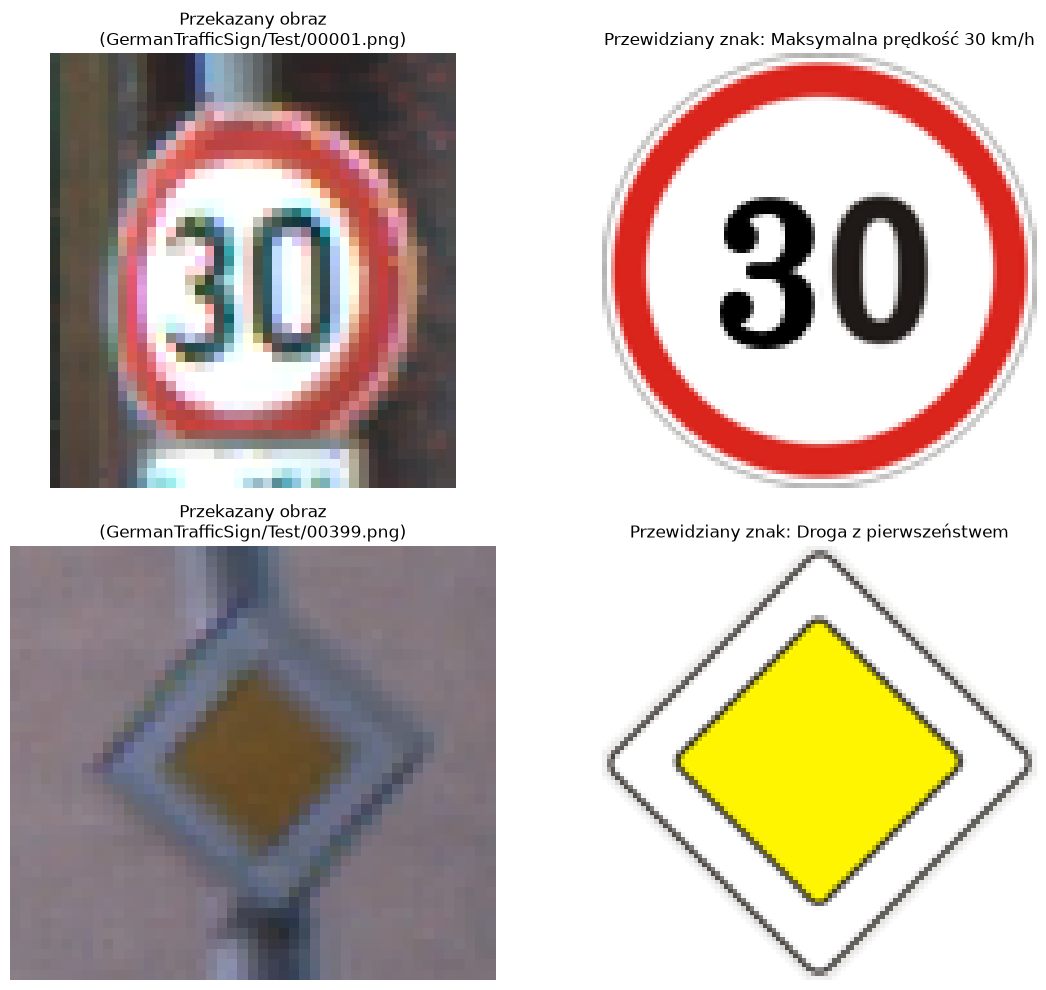

In [11]:
PredictSignFromImage(['GermanTrafficSign/Test/00001.png', 'GermanTrafficSign/Test/00399.png'], visualization=True)

## Funkcja działa także dla pojedynczo przekazanego zdjęcia

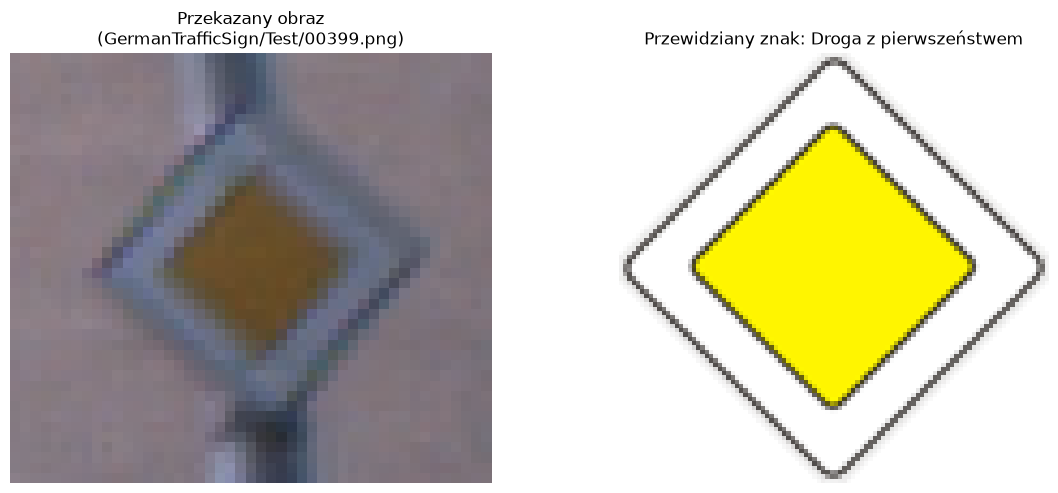

In [12]:
PredictSignFromImage('GermanTrafficSign/Test/00399.png', visualization=True)

## Przykład użycia funkcji dla kilku losowych zdjęć testowych

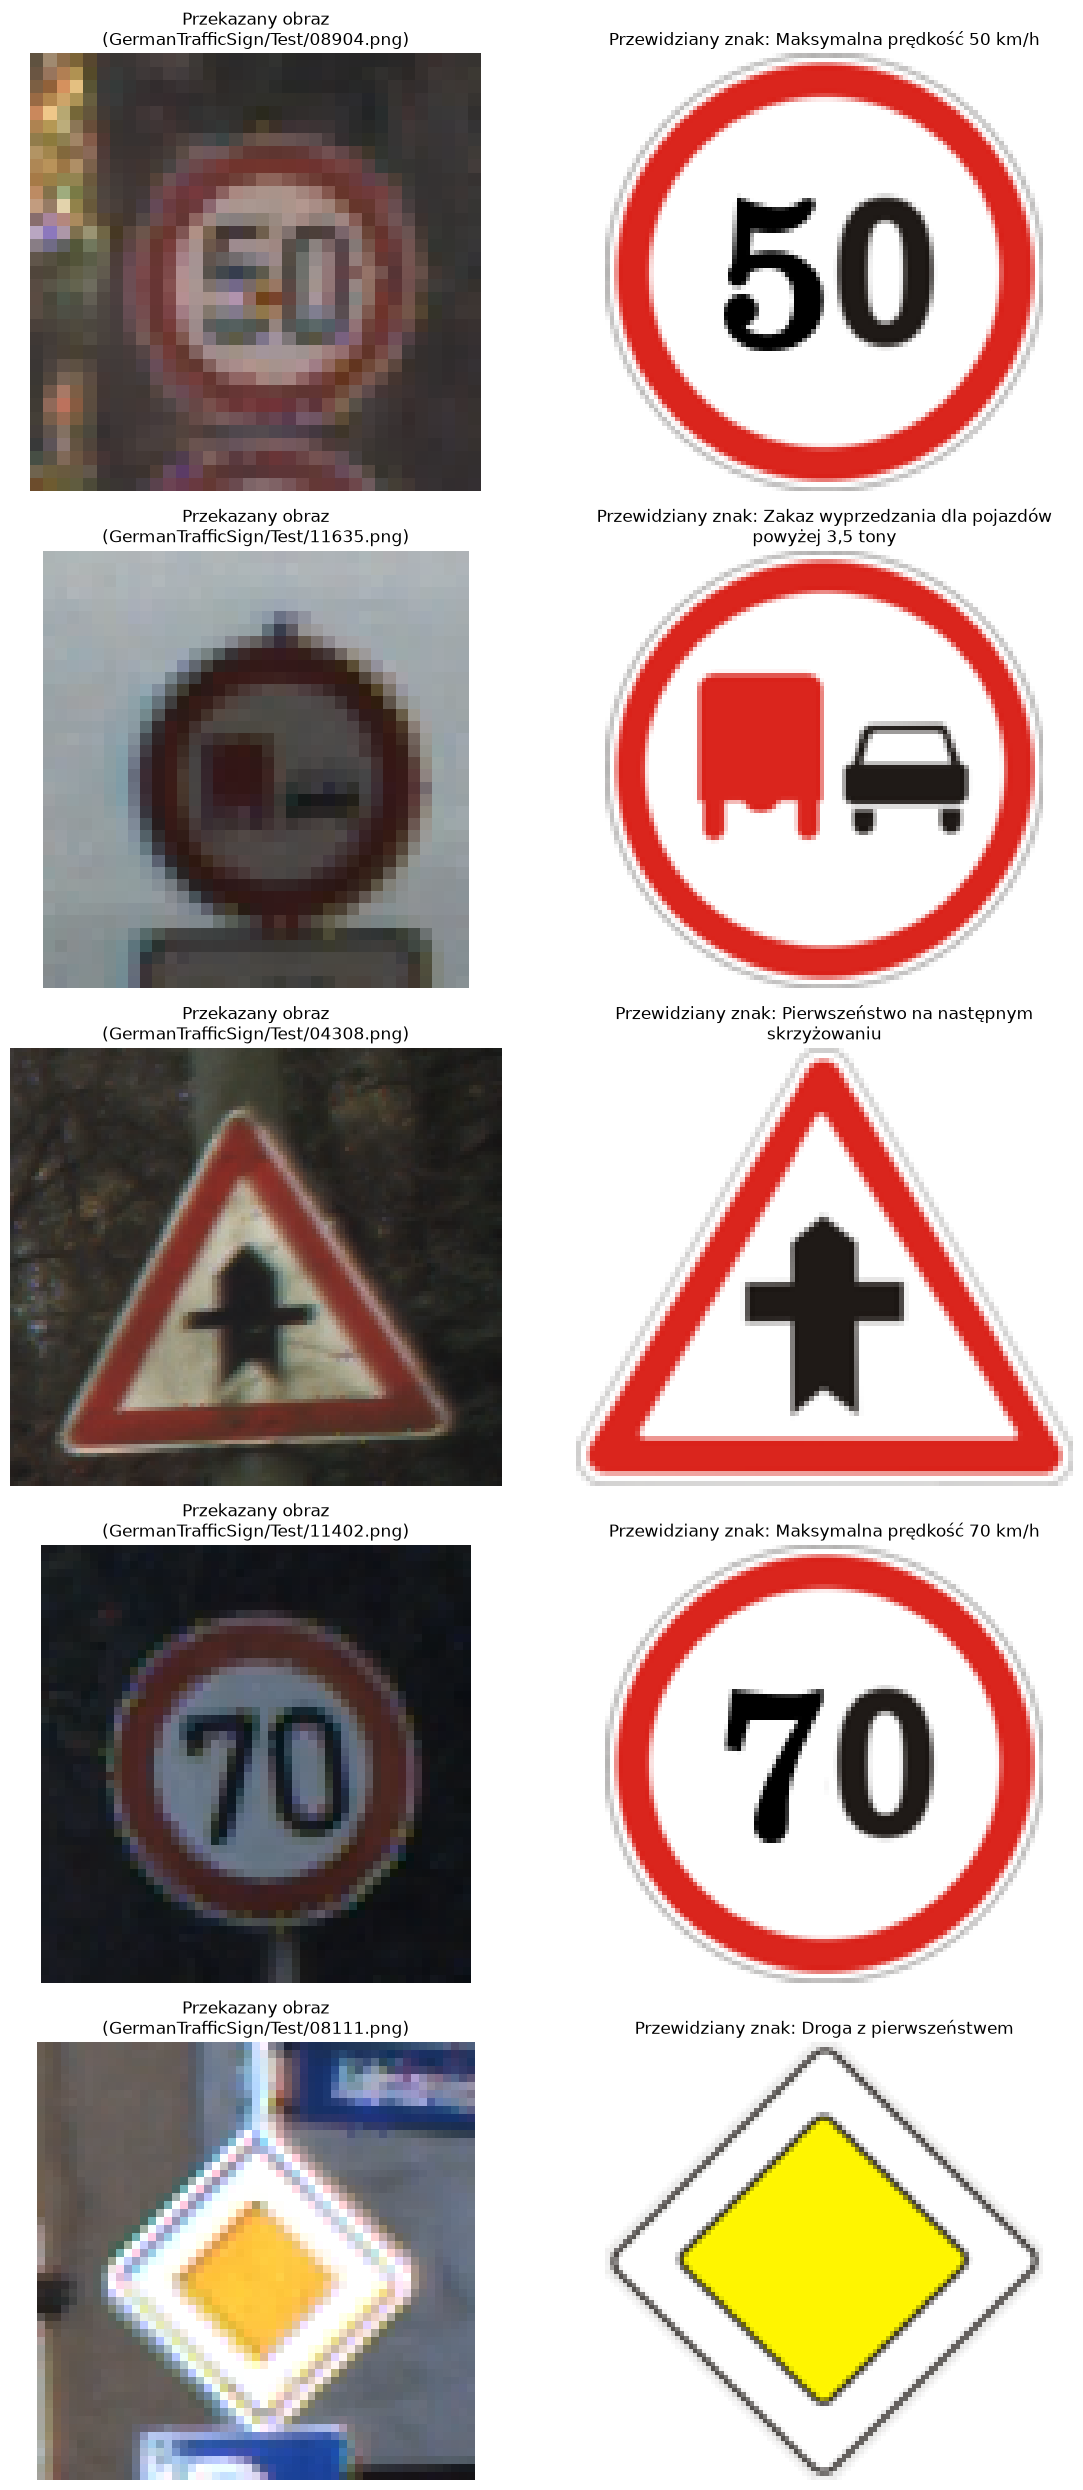

In [13]:
example_images = ('GermanTrafficSign/' + df_test['Path'].sample(n=5, random_state=42)).values.tolist()
PredictSignFromImage(example_images, visualization=True)

# Wyodrębnienie informacji z pliku utworzonego podczas treningu

In [14]:
training_information = []
with open('log_messages.txt') as f:
    for row in f.readlines():
        pattern = r'Epoch \[(\d+)/100\], Loss: ([\d.]+), Validation: ([\d.e+-]+), Validation Accuracy: ([\d.]+)%.'
        log_message_numbers = re.search(pattern, row)
        training_information.append(
            {
                'Epoch': int(log_message_numbers.group(1)),
                'Loss': float(log_message_numbers.group(2)),
                'Validation': float(log_message_numbers.group(3)),
                'Validation Accuracy': float(log_message_numbers.group(4)) / 100
            }
        )
training_information_pd = pd.DataFrame(training_information)
training_information_pd

,Epoch,Loss,Validation,Validation Accuracy
0,1,1.2599,0.004711,0.9298
1,2,0.1413,0.014302,0.9722
2,3,0.0650,0.010933,0.9821
3,4,0.0431,0.000211,0.9906
4,5,0.0336,0.042049,0.9855
...,...,...,...,...
95,96,0.0000,0.000000,0.9949
96,97,0.0000,0.000000,0.9952
97,98,0.0000,0.000000,0.9952
98,99,0.0000,0.000000,0.9952


# Wykres dla funkcji strat oraz wykres skuteczności modelu na danych walidacyjnych w poszczególnych epokach

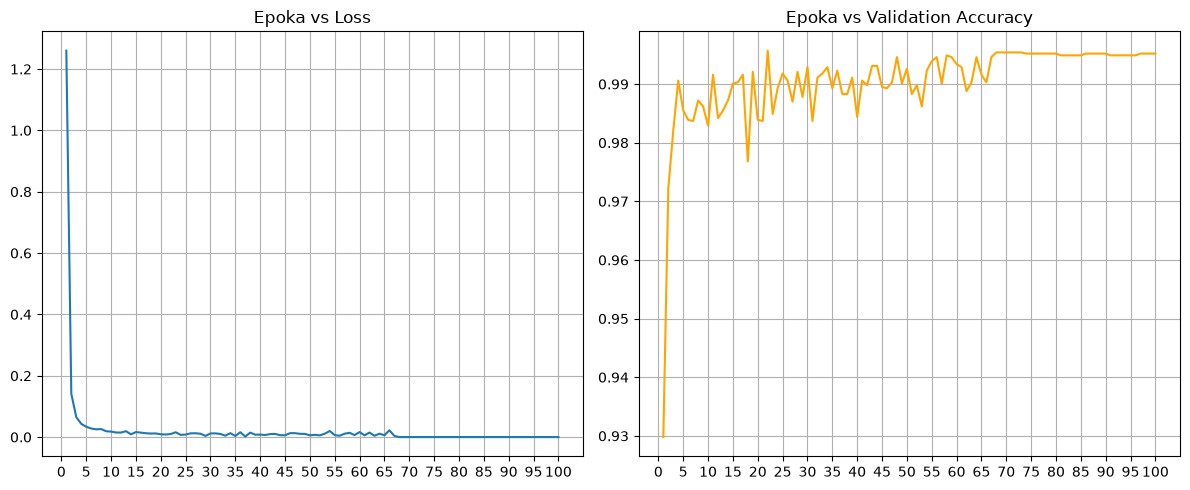

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(training_information_pd['Epoch'], training_information_pd['Loss'])
ax[0].set_title('Epoka vs Loss')
ax[0].set_xticks(range(0, 101, 5))
ax[0].grid()

ax[1].plot(training_information_pd['Epoch'], training_information_pd['Validation Accuracy'], color='orange')
ax[1].set_title('Epoka vs Validation Accuracy')
ax[1].set_xticks(range(0, 101, 5))
ax[1].grid()

plt.tight_layout()
plt.show()

# Predykcja modelu dla wszystkich danych testowych

In [16]:
model = GermanTrafficSignCNN().to(device)
model.load_state_dict(torch.load('CNN_GermanTrafficSign_best_model.pth'))

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

y_pred = []

for path in df_test['Path']:
    model.eval()
    
    image = Image.open('GermanTrafficSign/' + path)
    image = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        target = model(image)
        _, predicted = torch.max(target, 1)

    y_pred.append(predicted.cpu().item())

# Ilość poprawnych i niepoprawnych predykcji dla każdej klasy (recall - ile zdjęć model rozpoznał poprawnie dla tej klasy)

In [17]:
predictions_info = []
for class_id in range(0, 43):
    prediction_results = [1 if real_class_id == class_id and real_class_id == predicted_class_id
                          else 0 if real_class_id == class_id and real_class_id != predicted_class_id
                          else -1 for real_class_id, predicted_class_id in zip(df_test['ClassId'], y_pred)]
    predictions_info.append(
        {
            'ClassId': class_id,
            'Correct Predictions': prediction_results.count(1),
            'Incorrect Predictions': prediction_results.count(0),
        }
    )
predictions_info_pd = pd.DataFrame(predictions_info)
predictions_info_pd

,ClassId,Correct Predictions,Incorrect Predictions
0,0,50,10
1,1,702,18
2,2,746,4
3,3,437,13
4,4,641,19
5,5,586,44
6,6,121,29
7,7,432,18
8,8,434,16
9,9,479,1


# Skuteczność modelu w przewidywaniu poszczególnych klas na zbiorze testowym

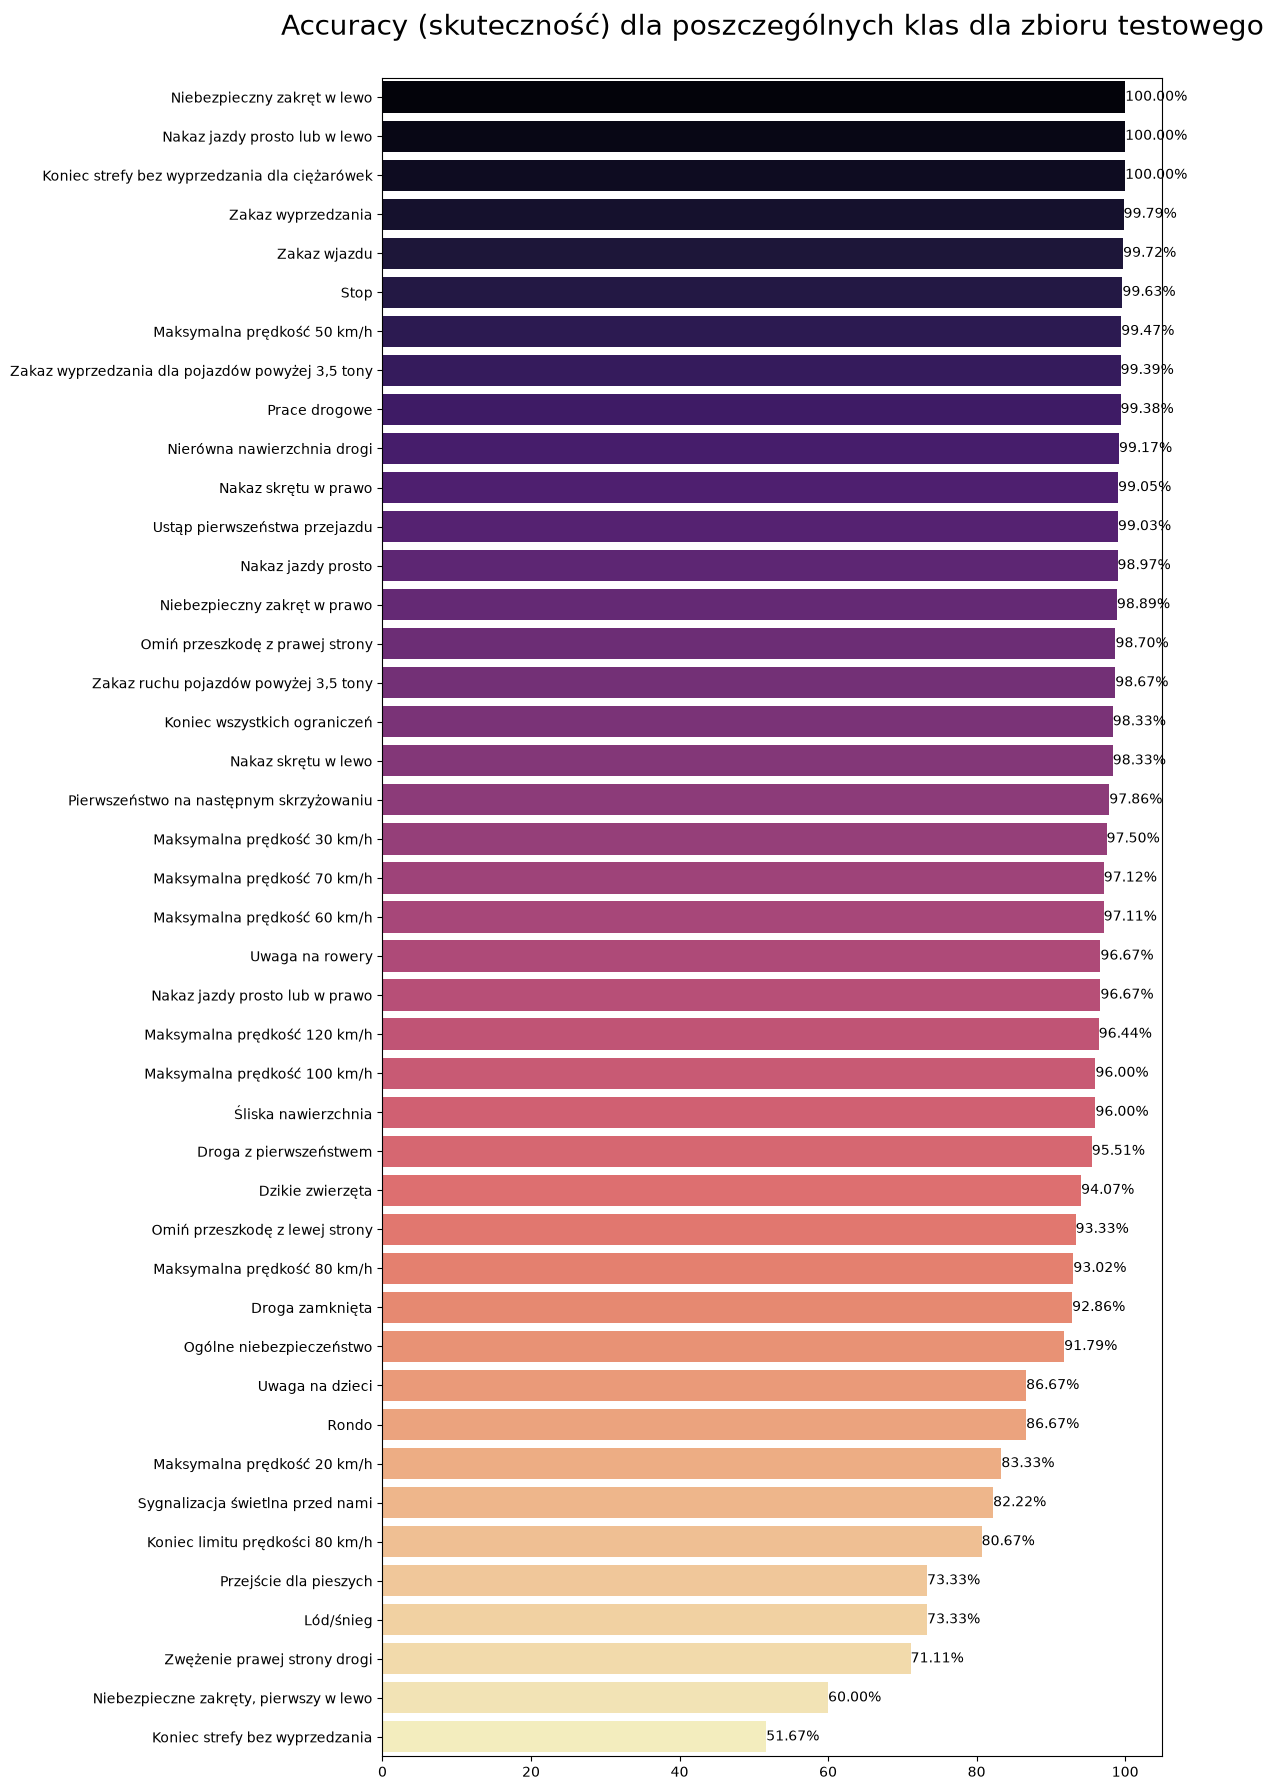

In [18]:
# https://www.geeksforgeeks.org/python/python-sort-python-dictionaries-by-key-or-value/
class_accuracy = {
    k:v for k, v in
    sorted(
        {
            road_sign_name[idx]: round(predictions_info_pd['Correct Predictions'].loc[predictions_info_pd['ClassId'] == idx].values[0] * 100 /
            (predictions_info_pd['Correct Predictions'].loc[predictions_info_pd['ClassId'] == idx].values[0] +
             predictions_info_pd['Incorrect Predictions'].loc[predictions_info_pd['ClassId'] == idx].values[0]), 2)
            for idx in range(0, 43)
        }.items(), key=lambda item: item[1], reverse=True
    )
}

plt.figure(figsize=(12, 18))

ax = sns.barplot(x=class_accuracy.values(), y=class_accuracy.keys(), orient='y', hue=class_accuracy.keys(), palette='magma')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.title('Accuracy (skuteczność) dla poszczególnych klas dla zbioru testowego\n', fontsize=20)
plt.tight_layout()
plt.show()

# Macierz Pomyłek (Confusion Matrix) dla wszystkich klas

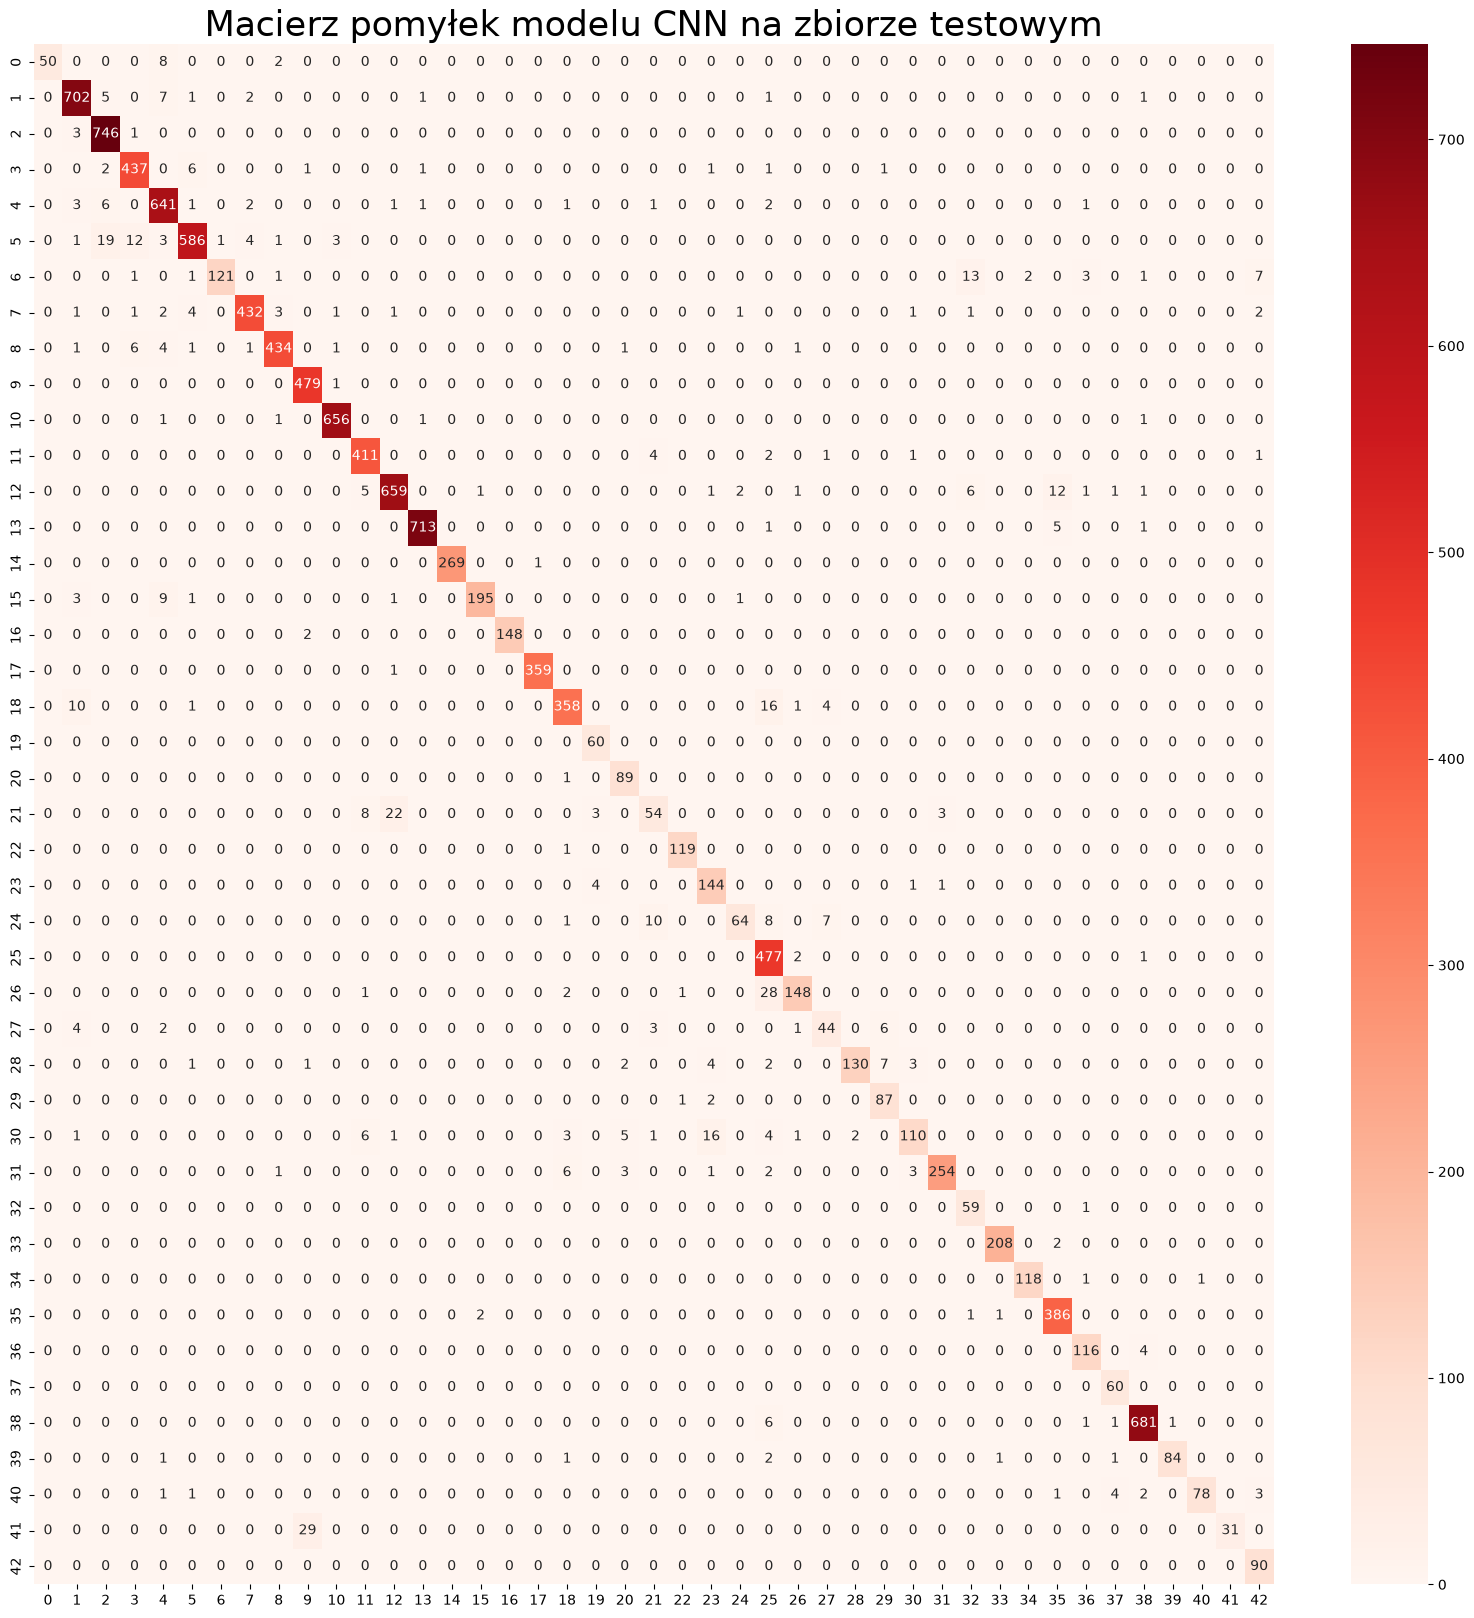

In [19]:
plt.figure(figsize=(20, 20))
sns.heatmap(confusion_matrix(df_test['ClassId'], y_pred), annot=True, fmt='d', cmap='Reds')
plt.title('Macierz pomyłek modelu CNN na zbiorze testowym', fontsize=25)
plt.show()

# Podsumowanie wyników uzyskanych przez poszczególną klasę

In [20]:
summary_class_model = [
    {
        'Numer klasy': idx,
        'Znak': road_sign_name[idx],
        'Accuracy Score': class_accuracy[road_sign_name[idx]],
        'Precision': np.around(precision_score(df_test['ClassId'], y_pred, average=None), 2)[idx],
        'Recall': np.around(recall_score(df_test['ClassId'], y_pred, average=None), 2)[idx],
        'F1-score': np.around(f1_score(df_test['ClassId'], y_pred, average=None), 2)[idx]
    }
    for idx in range(0, 43)
]

summary_class_model_sorted = pd.DataFrame(sorted(summary_class_model, key=lambda item: item['Accuracy Score'], reverse=True))
summary_class_model_sorted

,Numer klasy,Znak,Accuracy Score,Precision,Recall,F1-score
0,19,Niebezpieczny zakręt w lewo,100.00,0.90,1.00,0.94
1,37,Nakaz jazdy prosto lub w lewo,100.00,0.90,1.00,0.94
2,42,Koniec strefy bez wyprzedzania dla ciężarówek,100.00,0.87,1.00,0.93
3,9,Zakaz wyprzedzania,99.79,0.94,1.00,0.97
4,17,Zakaz wjazdu,99.72,1.00,1.00,1.00
5,14,Stop,99.63,1.00,1.00,1.00
6,2,Maksymalna prędkość 50 km/h,99.47,0.96,0.99,0.98
7,10,"Zakaz wyprzedzania dla pojazdów powyżej 3,5 tony",99.39,0.99,0.99,0.99
8,25,Prace drogowe,99.38,0.86,0.99,0.92
9,22,Nierówna nawierzchnia drogi,99.17,0.98,0.99,0.99
